# **Tugas 8 : Clustering dengan Fuzzy C-means**

**Nama : Achmad Baharuddin Akbar**

**NIM  : 210411100001**

In [326]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [327]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [328]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Mayapada Hospital Pakai Teknik Bronkoskopi Cry...,"Kamis, 28 Nov 2024 11:30 WIB",Jakarta - Kesehatan paru-paru dapat terancam o...,Kesehatan,Jakarta Kesehatan paruparu dapat terancam ole...,jakarta kesehatan paruparu dapat terancam ole...,"['jakarta', 'kesehatan', 'paruparu', 'dapat', ...",jakarta kesehatan paruparu terancam faktor gay...
1,"Dunia Hadapi Ancaman 'Kebal' Antibiotik, Puluh...","Kamis, 28 Nov 2024 11:03 WIB",Jakarta - Temuan antibiotik menjadi salah satu...,Kesehatan,Jakarta Temuan antibiotik menjadi salah satu ...,jakarta temuan antibiotik menjadi salah satu ...,"['jakarta', 'temuan', 'antibiotik', 'menjadi',...",jakarta temuan antibiotik salah terobosan medi...
2,Mayapada Hospital Hadirkan Layanan Modern Dete...,"Kamis, 28 Nov 2024 10:59 WIB",Jakarta - Kanker payudara menjadi salah satu p...,Kesehatan,Jakarta Kanker payudara menjadi salah satu pe...,jakarta kanker payudara menjadi salah satu pe...,"['jakarta', 'kanker', 'payudara', 'menjadi', '...",jakarta kanker payudara salah penyakit serius ...
3,"Daftar Makanan yang Bisa Bikin Panjang Umur, S...","Kamis, 28 Nov 2024 10:35 WIB",Jakarta - Siapa yang tidak ingin hidup lebih l...,Kesehatan,Jakarta Siapa yang tidak ingin hidup lebih la...,jakarta siapa yang tidak ingin hidup lebih la...,"['jakarta', 'siapa', 'yang', 'tidak', 'ingin',...",jakarta hidup sehat pola makan berperan memper...
4,Trump Tunjuk Pengkritik Vaksin COVID-19 Pimpin...,"Kamis, 28 Nov 2024 10:00 WIB",Jakarta - Presiden terpilih AS Donald Trump me...,Kesehatan,Jakarta Presiden terpilih AS Donald Trump men...,jakarta presiden terpilih as donald trump men...,"['jakarta', 'presiden', 'terpilih', 'as', 'don...",jakarta presiden terpilih as donald trump dr j...


In [329]:
texts = df['Filtering/stopword removal']

In [330]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [331]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 3191)

In [332]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=1.5, max_iter=1000, error=0.00001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9384882305315918, ARI=0.000808721249959564, NMI=0.03555936072748941
Iterasi dengan n_components=3: Silhouette=0.8218742089931235, ARI=0.01701445012943135, NMI=0.10806496399729751
Iterasi dengan n_components=4: Silhouette=0.7830594775749598, ARI=0.01701445012943135, NMI=0.10806496399729751
Iterasi dengan n_components=5: Silhouette=0.7475495856202385, ARI=0.011460342675592873, NMI=0.05611196255773773
Iterasi dengan n_components=6: Silhouette=0.7159425378059875, ARI=0.006713123426611697, NMI=0.03230741979513904
Iterasi dengan n_components=7: Silhouette=0.6840311683294058, ARI=-0.00035696756057293293, NMI=0.008943110719578682
Iterasi dengan n_components=8: Silhouette=0.6598469842531456, ARI=-0.004888426933445935, NMI=0.0
Iterasi dengan n_components=9: Silhouette=0.15741507055406326, ARI=0.6044186131938011, NMI=0.5048484896887586
Iterasi dengan n_components=10: Silhouette=0.11171192950233134, ARI=0.7721314419105764, NMI=0.7287008798015754
Iterasi 

In [333]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9384882305315918
Best ARI is achieved by n_components=10 with score: 0.7721314419105764
Best NMI is achieved by n_components=10 with score: 0.7287008798015754


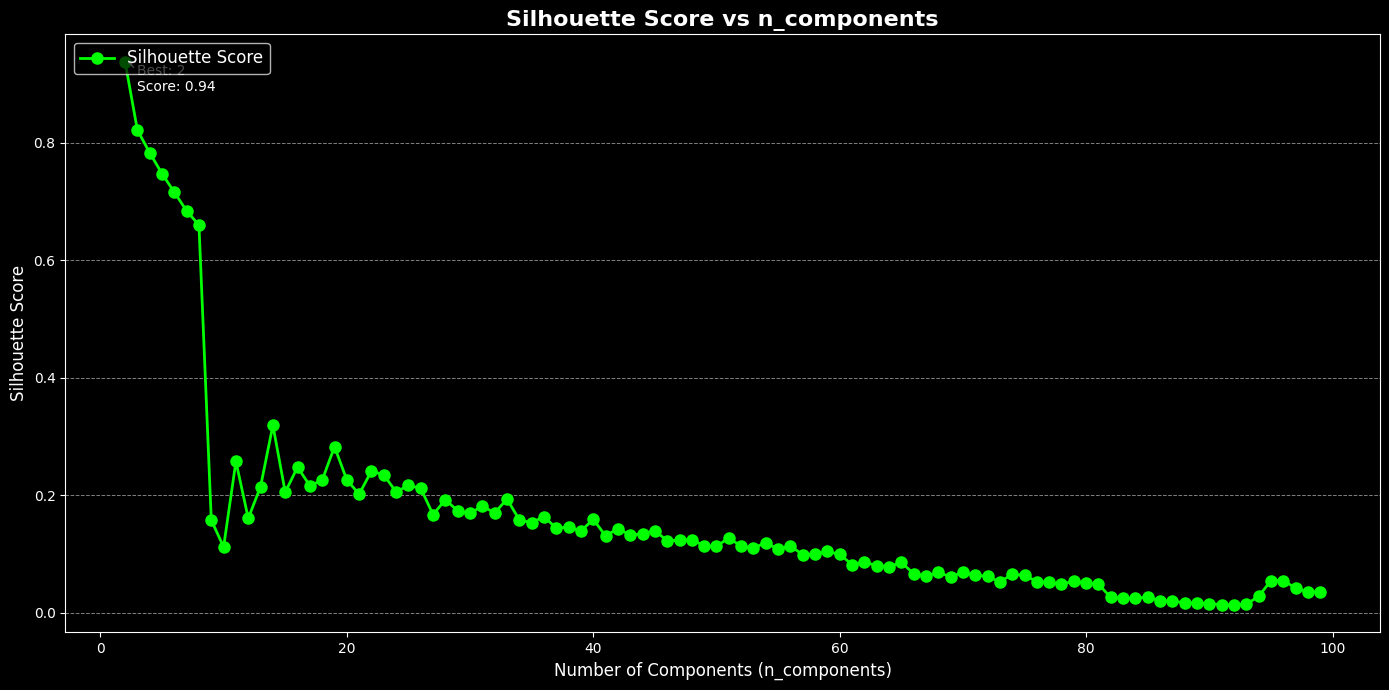

In [334]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.1117
Jumlah data pada setiap cluster:
Cluster
0    56
1    44
Name: count, dtype: int64


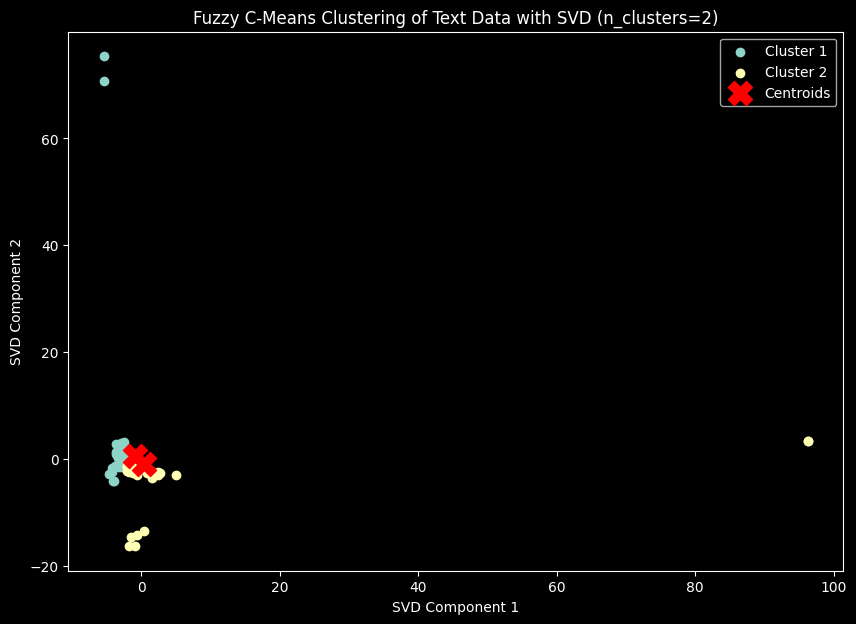

In [335]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv('/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv')
data = df['Filtering/stopword removal']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=10 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)

# Fuzzy C-Means Clustering
n_clusters = 2  # Ganti sesuai kebutuhan
fcm = FCM(n_clusters=n_clusters, m=1.5, max_iter=1000, epsilon=0.00001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:,0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [336]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal,Cluster
0,Mayapada Hospital Pakai Teknik Bronkoskopi Cry...,"Kamis, 28 Nov 2024 11:30 WIB",Jakarta - Kesehatan paru-paru dapat terancam o...,Kesehatan,Jakarta Kesehatan paruparu dapat terancam ole...,jakarta kesehatan paruparu dapat terancam ole...,"['jakarta', 'kesehatan', 'paruparu', 'dapat', ...",jakarta kesehatan paruparu terancam faktor gay...,0
1,"Dunia Hadapi Ancaman 'Kebal' Antibiotik, Puluh...","Kamis, 28 Nov 2024 11:03 WIB",Jakarta - Temuan antibiotik menjadi salah satu...,Kesehatan,Jakarta Temuan antibiotik menjadi salah satu ...,jakarta temuan antibiotik menjadi salah satu ...,"['jakarta', 'temuan', 'antibiotik', 'menjadi',...",jakarta temuan antibiotik salah terobosan medi...,0
2,Mayapada Hospital Hadirkan Layanan Modern Dete...,"Kamis, 28 Nov 2024 10:59 WIB",Jakarta - Kanker payudara menjadi salah satu p...,Kesehatan,Jakarta Kanker payudara menjadi salah satu pe...,jakarta kanker payudara menjadi salah satu pe...,"['jakarta', 'kanker', 'payudara', 'menjadi', '...",jakarta kanker payudara salah penyakit serius ...,0
3,"Daftar Makanan yang Bisa Bikin Panjang Umur, S...","Kamis, 28 Nov 2024 10:35 WIB",Jakarta - Siapa yang tidak ingin hidup lebih l...,Kesehatan,Jakarta Siapa yang tidak ingin hidup lebih la...,jakarta siapa yang tidak ingin hidup lebih la...,"['jakarta', 'siapa', 'yang', 'tidak', 'ingin',...",jakarta hidup sehat pola makan berperan memper...,0
4,Trump Tunjuk Pengkritik Vaksin COVID-19 Pimpin...,"Kamis, 28 Nov 2024 10:00 WIB",Jakarta - Presiden terpilih AS Donald Trump me...,Kesehatan,Jakarta Presiden terpilih AS Donald Trump men...,jakarta presiden terpilih as donald trump men...,"['jakarta', 'presiden', 'terpilih', 'as', 'don...",jakarta presiden terpilih as donald trump dr j...,0
...,...,...,...,...,...,...,...,...,...
95,"Demi Traktir Pacar Gratis, Pria Ini Selipkan S...","Selasa, 26 Nov 2024 16:00 WIB",Jakarta - Traktir pacar di restoran tapi tak m...,Kuliner,Jakarta Traktir pacar di restoran tapi tak ma...,jakarta traktir pacar di restoran tapi tak ma...,"['jakarta', 'traktir', 'pacar', 'di', 'restora...",jakarta traktir pacar restoran bayar pria modu...,1
96,"Surga Kuliner Jakarta Barat, Ada Makanan Legen...","Selasa, 26 Nov 2024 15:30 WIB",Jakarta - Belakangan ini eksistensi Jakarta Ba...,Kuliner,Jakarta Belakangan ini eksistensi Jakarta Bar...,jakarta belakangan ini eksistensi jakarta bar...,"['jakarta', 'belakangan', 'ini', 'eksistensi',...",jakarta eksistensi jakarta barat surga kuliner...,1
97,"5 Cara Atasi Food Coma, Anti Ngantuk Usai Maka...","Selasa, 26 Nov 2024 15:00 WIB",Jakarta - Usai makan banyak terutama ketika ma...,Kuliner,Jakarta Usai makan banyak terutama ketika mak...,jakarta usai makan banyak terutama ketika mak...,"['jakarta', 'usai', 'makan', 'banyak', 'teruta...",jakarta makan makan siang kantuk kerap muncul ...,0
98,Ada Beragam Sajian Hong Kong Lezat di Restoran...,"Selasa, 26 Nov 2024 14:30 WIB",Jakarta - Satu lagi restoran seafood ala Hong ...,Kuliner,Jakarta Satu lagi restoran seafood ala Hong K...,jakarta satu lagi restoran seafood ala hong k...,"['jakarta', 'satu', 'lagi', 'restoran', 'seafo...",jakarta restoran seafood ala hong kong hadir j...,1


In [337]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

print(len(cluster_0))
print(len(cluster_1))

    id   kategori  Cluster
0    0  Kesehatan        0
1    1  Kesehatan        0
2    2  Kesehatan        0
3    3  Kesehatan        0
4    4  Kesehatan        0
..  ..        ...      ...
95  95    Kuliner        1
96  96    Kuliner        1
97  97    Kuliner        0
98  98    Kuliner        1
99  99    Kuliner        1

[100 rows x 3 columns]
Anggota Cluster 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 58, 59, 60, 61, 85, 97]
Anggota Cluster 1: [50, 51, 52, 53, 54, 55, 56, 57, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99]
56
44


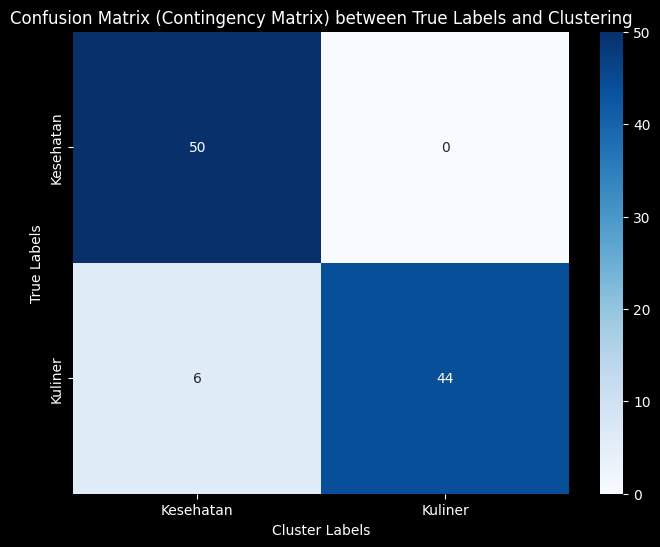

Confusion Matrix (Contingency Matrix):
[[50  0]
 [ 6 44]]


In [338]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [339]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.1117


In [340]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
data = df['Filtering/stopword removal'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=1.5,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.00001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Tuning parameter TfidfVectorizer
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('scaler', StandardScaler(with_mean=False)),
    ('svd', TruncatedSVD(n_components=10)),
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [341]:
from fcmeans import FCM
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import joblib

# Fungsi untuk menerapkan FCM
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,
        m=1.5,
        max_iter=1000,
        epsilon=0.00001,
        random_state=42
    )
    fcm.fit(X)
    return fcm

# Pipeline tanpa FCM
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=10))  # Reduksi Dimensi
])

# Fit pipeline pada data
transformed_data = pipeline.fit_transform(data)  # Pastikan 'data' sudah diproses sebelumnya

# Jalankan FCM pada data yang sudah diproses
fcm_result = fit_fcm(transformed_data)

# Simpan pipeline dan hasil FCM dalam satu file (tuple)
joblib.dump((pipeline, fcm_result), 'fcm_pipeline.pkl')

['fcm_pipeline.pkl']